In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing

In [2]:
data = fetch_california_housing()
df = pd.DataFrame(data.data,columns=data.feature_names)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
x = df
y = data.target

In [4]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [5]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [6]:
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)
sc_y = StandardScaler()
y_train = sc_y.fit_transform(np.array(y_train).reshape(-1,1))

In [7]:
regressor = LinearRegression()
regressor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred_sc = regressor.predict(x_test)
y_pred = sc_y.inverse_transform(y_pred_sc)

In [9]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [10]:
score = r2_score(y_test,y_pred)
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.5957702326061665
MAE: 0.5272474538305952
MSE: 0.5305677824766752


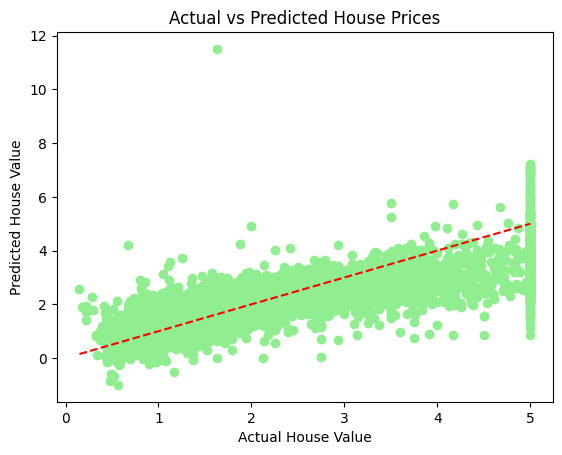

In [11]:
plt.scatter(y_test,y_pred,color="lightgreen")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color="red",linestyle="--")
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Prices')
plt.show()

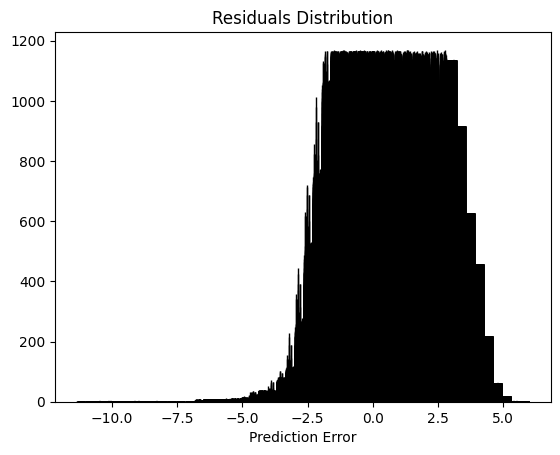

In [12]:
residuals = y_test - y_pred

plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Prediction Error')
plt.title('Residuals Distribution')
plt.show()


In [13]:
from sklearn.model_selection import cross_val_score
mse = cross_val_score(regressor,x_train,y_train,scoring='neg_mean_squared_error',cv=5)
np.mean(mse)

np.float64(-0.3932424844849676)

In [14]:
y_test

array([0.477  , 0.458  , 5.00001, ..., 2.184  , 1.194  , 2.098  ],
      shape=(6192,))

In [15]:
y_pred

array([[0.72604907],
       [1.76743383],
       [2.71092161],
       ...,
       [2.07465531],
       [1.57371395],
       [1.82744133]], shape=(6192, 1))

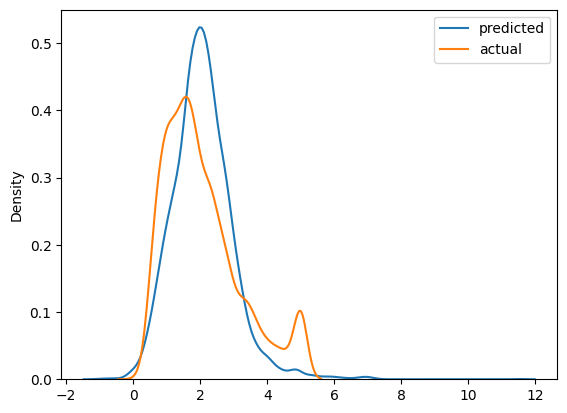

In [16]:
import seaborn as sns
sns.kdeplot(y_pred,label="predicted")
sns.kdeplot(y_test,label="actual")
plt.legend()

In [17]:
y_train_pred = regressor.predict(x_train)
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.6093459727972159